# MetroPredict: measured retail analytics

Independent case study prepared for Eshwar Vudhanthi. This notebook inspects the executed pipeline. Run `python run_project.py` from the project root to rebuild training and outputs. Public data only; no Metro Market receipts.

**Decision:** conditional pilot with a confidence-filtered list. Predictive gains are measured; revenue uplift is not.

In [1]:
from pathlib import Path
import json, sqlite3
import pandas as pd
from PIL import Image
ROOT = Path.cwd()
if ROOT.name == "notebooks": ROOT = ROOT.parent
assert (ROOT / "outputs/results.json").exists(), "Open from MetroPredict or its notebooks folder"
results = json.loads((ROOT / "outputs/results.json").read_text())
results

{'selected_on_validation': 'Gradient boosting', 'baseline_selected_on_validation': 'Frequent purchases', 'test_precision_at_8': 0.16470800577570993, 'test_baseline_precision_at_8': 0.15175276752767528, 'test_absolute_gain': 0.012955238248034656, 'test_relative_gain': 0.08537068851592443, 'cluster_bootstrap_95ci_absolute_gain': [0.010581047823028484, 0.015362353817335774], 'recommendation': 'PILOT', 'test_shopping_days': 6233, 'test_households': 708, 'test_eligible_day_coverage': 0.9929902819818385, 'decision_rule': 'Pilot readiness requires >=5% relative Precision@8 gain and household-clustered 95% CI above zero. Economics and live effects remain unproven.'}

## Source audit
The source has normalized 2017 dates and 2,469 households. Returns and invalid purchase rows are excluded from modeling. The coupon mapping has duplicates, so sales must never be joined directly to all coupon-product rows.

In [2]:
audit = json.loads((ROOT / "outputs/data_audit.json").read_text())
pd.DataFrame([audit["source"]]).T

,0
households,2469
baskets,155848
date_min,2017-01-01 06:53:26
date_max,2017-12-31 23:01:20
sales_value,4596039.58
excluded_nonpositive_quantity_or_negative_sales,8869
missing_product_metadata_lines,4836
shopping_days,127347


## SQL: category scale
The query runs against the delivered SQLite warehouse. Recorded sales are historical; they are not retailer profit.

In [3]:
con = sqlite3.connect(ROOT / "data/processed/metropredict.sqlite")
category = pd.read_sql_query("""SELECT product_category, COUNT(DISTINCT household_id) households, ROUND(SUM(sales_value),2) sales_value FROM v_sales_lines WHERE product_category IS NOT NULL GROUP BY product_category ORDER BY sales_value DESC LIMIT 10""", con)
con.close()
category

,product_category,households,sales_value
0,COUPON/MISC ITEMS,1640,385971.75
1,SOFT DRINKS,2260,182124.21
2,BEEF,2011,176614.54
3,FLUID MILK PRODUCTS,2256,116360.68
4,CHEESE,2174,107011.61
5,FRZN MEAT/MEAT DINNERS,1775,93023.74
6,BAG SNACKS,2148,84943.85
7,BAKED BREAD/BUNS/ROLLS,2246,82429.70
8,BEERS/ALES,1298,82039.45
9,FROZEN PIZZA,1765,81175.04


## Frozen model comparison
Train April-September; select on October; test November-December. Three rules compete with logistic regression and gradient boosting. Each test day is scored from strictly earlier history. Precision@8 is averaged over shopping days.

In [4]:
comparison = pd.read_csv(ROOT / "outputs/model_comparison.csv")
comparison.loc[comparison["split"] == "test", ["model", "shopping_days", "precision_at_8", "recall_full_basket", "mean_hits"]]

,model,shopping_days,precision_at_8,recall_full_basket,mean_hits
5,Frequent purchases,6233,0.151753,0.143234,1.214022
6,Recent purchases,6233,0.108816,0.104074,0.870528
7,Replenishment rule,6233,0.115314,0.106877,0.922509
8,Logistic regression,6233,0.162482,0.152140,1.299856
9,Gradient boosting,6233,0.164708,0.153371,1.317664


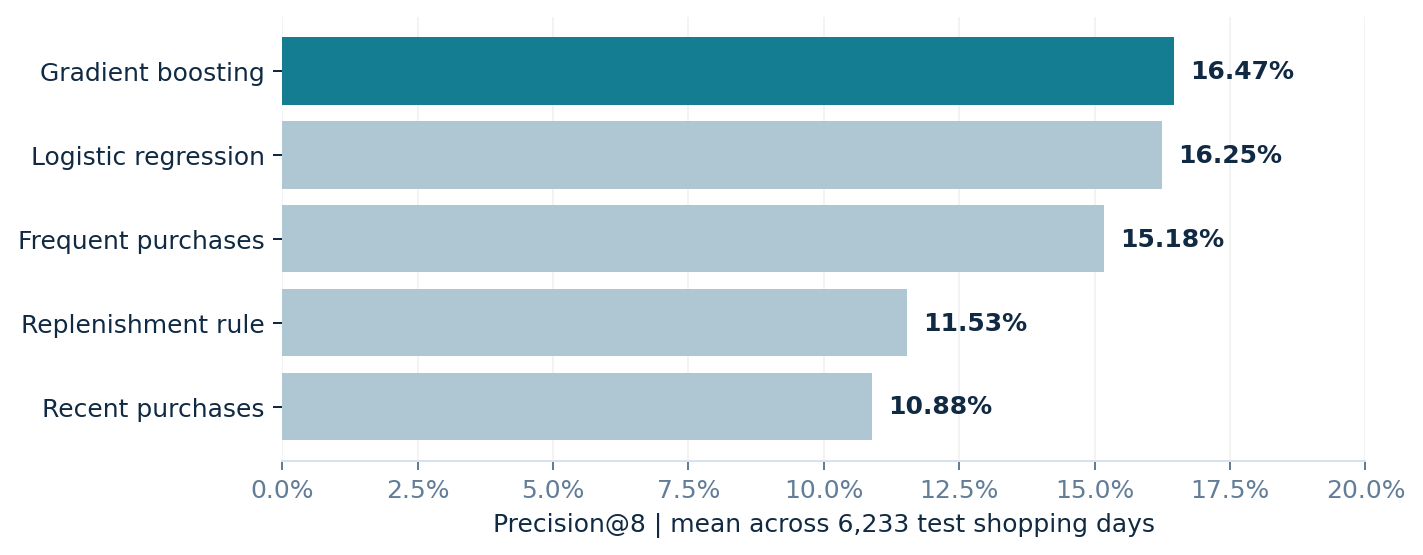

In [5]:
Image.open(ROOT / "reports/figures/model_comparison.png")

## Confidence-filtered policy
This is a secondary exploratory analysis. Threshold 0.30 was selected on validation, then evaluated once on test. Displayed-item precision and eligible-day coverage must be interpreted together.

In [6]:
policy = json.loads((ROOT / "outputs/policy_results.json").read_text())
policy

{'threshold': 0.3, 'shown_items': 10168, 'covered_days': 3553, 'eligible_days': 6233, 'day_coverage': 0.5700304829135248, 'displayed_item_precision': 0.36418174665617625, 'suggestions_per_covered_day': 2.8618069237264283, 'status': 'Exploratory threshold selected on validation', 'selection_rule': 'Among predefined thresholds with >=35% displayed-item validation precision and >=100 covered days, maximize validation day coverage.', 'validation_precision': 0.37256772224341855}

## Promotions: observational response
Denominator is household-campaign assignment. Boundary campaigns are excluded below. These rates do not measure causal uplift or campaign profitability.

In [7]:
pd.read_csv(ROOT / "outputs/campaign_types.csv")

,campaign_type,campaigns,assigned_household_campaigns,redeeming_household_campaigns,household_campaign_redemption_rate
0,Type A,4,3647,604,0.165616
1,Type B,12,1709,121,0.070802
2,Type C,3,301,21,0.069767


## Financial sensitivity
All behavioral and cost inputs are explicit assumptions. Accepted recommendations only create additional revenue to the extent that they change purchases after substitution and timing effects. The filtered capacity includes days with no suggestions.

In [8]:
finance = pd.read_csv(ROOT / "outputs/financial_scenarios.csv")
central = finance[(finance.adoption == .25) & (finance.acceptance == .1) & (finance.incremental_share == .1) & (finance.margin_rate == .25) & (finance.coupon_per_accepted_item == 0)]
central[["capacity_policy", "recommendations_per_eligible_day", "accepted_items", "incremental_revenue", "net_monthly_contribution", "break_even_incremental_share"]]

,capacity_policy,recommendations_per_eligible_day,accepted_items,incremental_revenue,net_monthly_contribution,break_even_incremental_share
104,Fixed eight,8.000000,20000.000000,6000.000000,-3500.000000,0.333333
320,Confidence filtered,1.631317,4078.292957,1223.487887,-4694.128028,1.634671


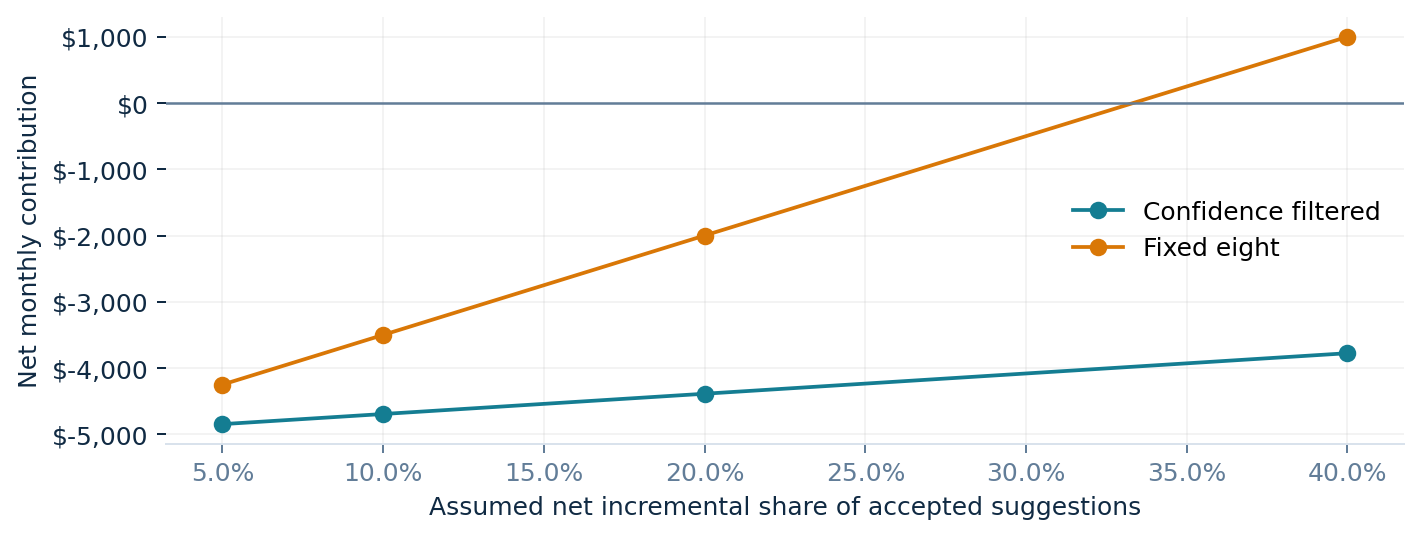

In [9]:
Image.open(ROOT / "reports/figures/financial_sensitivity.png")

## Next business decision
Use a budget-capped household-randomized experiment comparing existing purchase history, reminders alone, and reminders plus offers. Measure convenience and net contribution over a prespecified horizon. Do not convert the 8.5% ranking improvement into a sales-lift claim.

Your purchases can be added using `personal/purchases_template.csv`; see `docs/PERSONAL_DATA.md`. Full methodology, source checksums, tests and Tableau validation limitations accompany this notebook.